## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10000

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=3,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([1/3, 1/3, 1/3]))

## MOLA

19:42:48 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:42:48 | DEBUG | machinemoo | Finding 1th individual minimum
19:42:48 | DEBUG | machinemoo | Finding 2th individual minimum
19:42:48 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/mlm

new solution added [0.61523737 0.61798065 0.79301504]


19:42:48 | DEBUG | machinemoo | Calculated weights: [0.99268753 0.         0.00731247]
19:42:48 | DEBUG | machinemoo | Importance: 0.0008288751725503696
19:42:48 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
19:42:48 | DEBUG | machinemoo | Iteration 2
19:42:48 | DEBUG | machinemoo | Solutions list: [array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


new solution added [0.61294861 0.61946406 0.8736994 ]


19:42:48 | DEBUG | machinemoo | Calculated weights: [0.97241568 0.         0.02758432]
19:42:48 | DEBUG | machinemoo | Importance: 0.0008119485637896329
19:42:48 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
19:42:48 | DEBUG | machinemoo | Iteration 3
19:42:48 | DEBUG | machinemoo | Solutions list: [array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


...

19:42:51 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:51 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:51 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:51 | DEBUG | machinemoo | Iteration 49
19:42:51 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

new solution dominated [0.62168929 0.62981861 0.22138124]


19:42:51 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:51 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:51 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:51 | DEBUG | machinemoo | Iteration 50
19:42:51 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

new solution dominated [0.62168929 0.62981861 0.22138124]


19:42:51 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:51 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:51 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:51 | DEBUG | machinemoo | Iteration 51
19:42:51 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

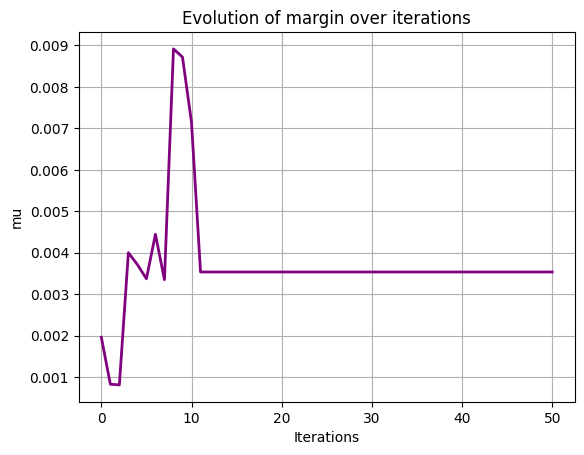

19:42:51 | INFO | machinemoo | Fit runtime: 3.26 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [10]:
objs_all = np.array([s.objs for s in moopt.history_list])

In [11]:
objs[:, 0:2].shape

(15, 2)

In [12]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def plot_pareto_plotly_3d(
        methods,
        point     = None,
        save_path = None,
        labels    = None,
        color     = ['#FF5C8D', '#4BD6A0', '#9D5CFF'],
        point_label = "Baseline Model",
        title       = "Pareto Frontier",
        fontsize    = 20,
        figsize     = (10, 7),
) -> None:

    num_plots = len(methods)
    
    layout_configs = {
        1: (1, 1),
        2: (1, 2),
        3: (1, 3),
        4: (2, 2),
        5: (2, 3),
        6: (2, 3),
        7: (3, 3),
        8: (3, 3),
        9: (3, 3)
    }

    rows, cols = layout_configs[num_plots]
    positions  = [(i,j) for i in range(rows) for j in range(cols)]

    first_key      = next(iter(methods))
    num_objectives = methods[first_key].shape[1]
    default_labels = [f"Objective {i+1}" for i in range(num_objectives)]
    labels         = labels if labels else default_labels
    
    fig = make_subplots(rows=rows, 
                        cols=cols, 
                        subplot_titles=list(methods.keys()),
                        specs=[[{'type': 'scene'} for _ in range(cols)] for _ in range(rows)])

    for i, ((row, col), (key, values)) in enumerate(zip(positions, methods.items())):
        scene_id = f'scene{(row * cols + col + 1)}'
        fig.add_trace(
            go.Scatter3d(
                x=values[:, 0],
                y=values[:, 1],
                z=values[:, 2],
                mode='markers',
                marker=dict(size=12, 
                            color=color[i % len(color)], 
                            line=dict(color='black', width=1))
            ),
            row=row + 1,
            col=col + 1
        )
    
        if point is not None:
            fig.add_trace(
                go.Scatter3d(
                    x=[point[0]],
                    y=[point[1]],
                    z=[point[2]],
                    mode='markers+text',
                    name=point_label,
                    marker=dict(size=15, color='black', symbol='cross'),
                    text=[point_label],
                    textposition='top right',
                ),
                row=row+1,
                col=col+1,
            )

        fig.update_layout({
            scene_id: dict(
                xaxis_title=labels[0],
                yaxis_title=labels[1],
                zaxis_title=labels[2],
                xaxis=dict(showgrid=True, gridcolor='lightgray'),
                yaxis=dict(showgrid=True, gridcolor='lightgray'),
                zaxis=dict(showgrid=True, gridcolor='lightgray'),
            )
        })

    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=fontsize, color='black')

    fig.update_layout(
        height=int(figsize[1] * 100),
        width=int(figsize[0] * 100),
        title=dict(text=title, x=0.5, xanchor='center', font=dict(size=fontsize)),
        plot_bgcolor='white',
        paper_bgcolor='white',
        font=dict(size=fontsize, color='black'),
        margin=dict(l=60, r=40, t=80, b=60),
        showlegend=False
    )
    
    fig.show()
    
    if save_path is not None:
        fig.write_html(save_path)

In [13]:
title = "Conflict between losses and reg coef in training"
plot_pareto_plotly_3d(methods={'mola': objs, 'mola2': objs},
            labels=("White", "Non-White", "Reg Coef"), 
            #title=title,
            point = equal.objs,
            #save_path='images/3_objs_mola.png',
            figsize=(15,10),
            fontsize=15,
            )

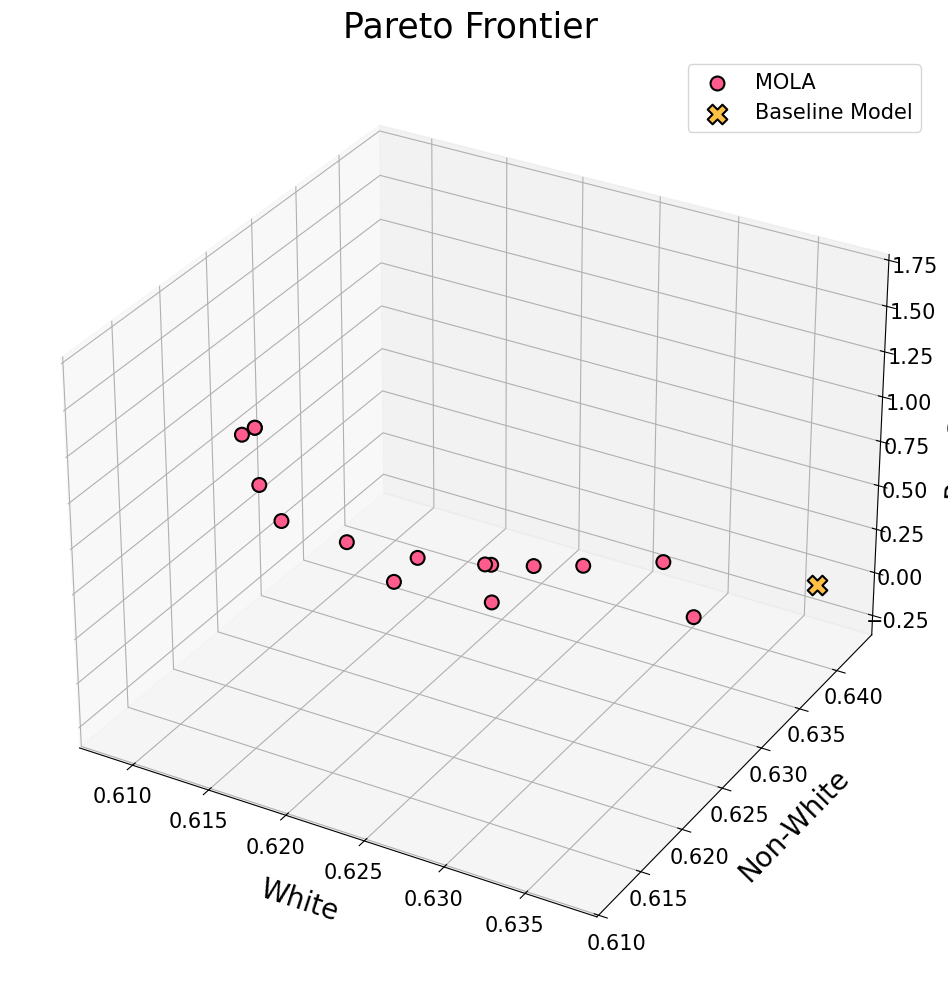

In [14]:
title = "Conflict between losses and reg coef in training"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White", "Reg Coef"), 
            #title=title,
            point = equal.objs,
            color="#FF5C8D",
            save_path='images/3_objs_mola.png',
            figsize=(10,10),
            fontsize=20,
            s_factor=2
            )

In [15]:
plot_pareto_plotly(methods={'mola': objs},
            labels=("White", "Non-White", "Reg Coef"), 
            #title=title,
            point = equal.objs,
            #color="#FF5C8D",
            save_path='images/3_objs_mola_plotly.png',
            figsize=(10,10),
            fontsize=20,
            )

19:42:52 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:42:52 | DEBUG | machinemoo | Finding 1th individual minimum
19:42:52 | DEBUG | machinemoo | Finding 2th individual minimum
19:42:52 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning:

divide by zero encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning:

invalid value encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning:

invalid value encountered in divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWar

new solution added [0.61523737 0.61798065 0.79301504]


19:42:52 | DEBUG | machinemoo | Calculated weights: [0.99268753 0.         0.00731247]
19:42:52 | DEBUG | machinemoo | Importance: 0.0008288751725503696
19:42:52 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
19:42:52 | DEBUG | machinemoo | Iteration 2
19:42:52 | DEBUG | machinemoo | Solutions list: [array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


new solution added [0.61294861 0.61946406 0.8736994 ]


19:42:52 | DEBUG | machinemoo | Calculated weights: [0.97241568 0.         0.02758432]
19:42:52 | DEBUG | machinemoo | Importance: 0.0008119485637896329
19:42:52 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
19:42:52 | DEBUG | machinemoo | Iteration 3
19:42:52 | DEBUG | machinemoo | Solutions list: [array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


...

19:42:55 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:55 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:55 | DEBUG | machinemoo | Iteration 49
19:42:55 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

new solution dominated [0.62168929 0.62981861 0.22138124]


19:42:55 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:55 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:55 | DEBUG | machinemoo | Iteration 50
19:42:55 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

new solution dominated [0.62168929 0.62981861 0.22138124]


19:42:55 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
19:42:55 | DEBUG | machinemoo | Importance: 0.0035365367306303686
19:42:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
19:42:55 | DEBUG | machinemoo | Iteration 51
19:42:55 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 

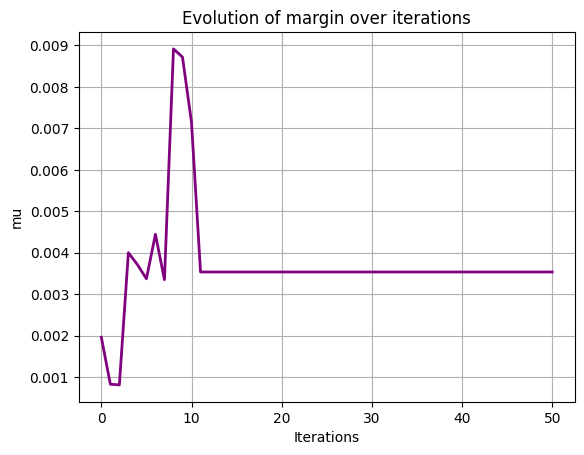

19:42:55 | INFO | machinemoo | Fit runtime: 3.38 seconds


In [16]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

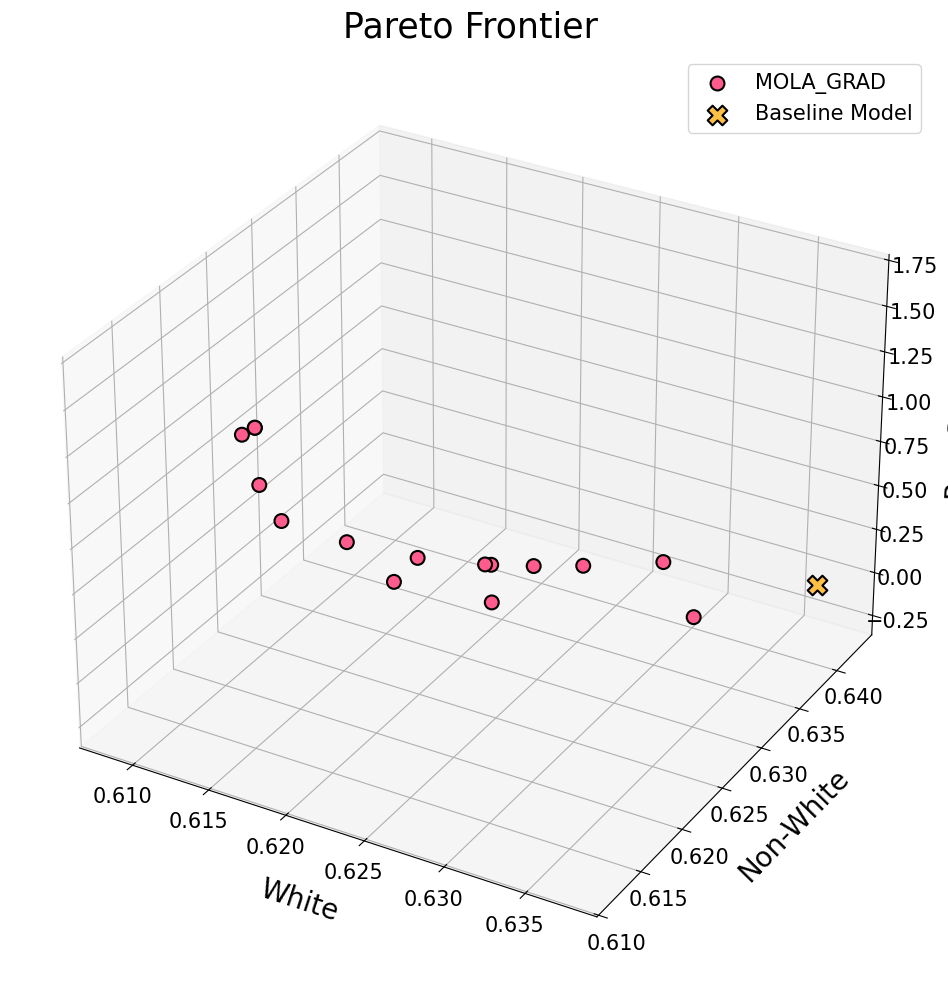

In [17]:
title = "Conflict between losses and reg coef in training"
plot_pareto(methods={'mola_grad': objs},
               labels=("White", "Non-White", "Reg Coef"), 
               #title=title,
               point = equal.objs,
               color="#FF5C8D",
               save_path='images/3_objs_mola_grad.png',
               figsize=(10,10),
               fontsize=20,
               s_factor=2
               )

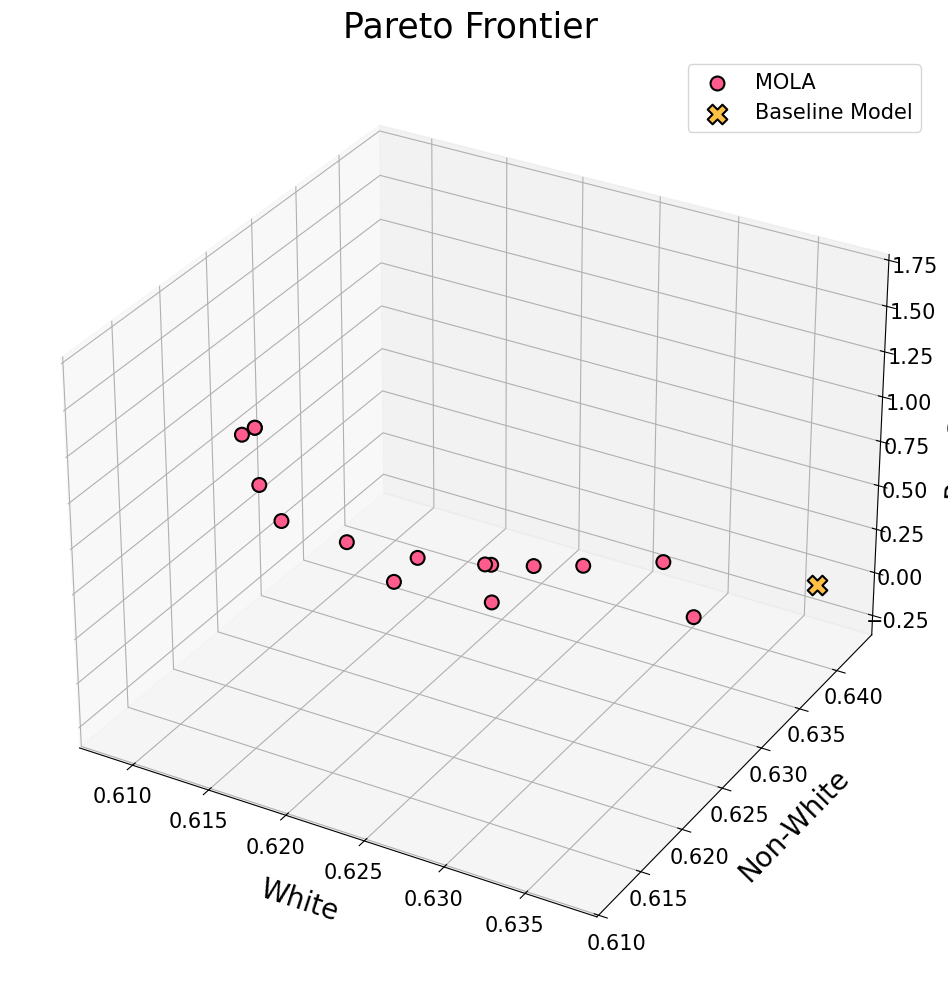

In [18]:
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White", "Reg Coef"), 
            #title=title,
            point = equal.objs,
            color="#FF5C8D",
            save_path='images/3_objs_mola_grad_plotly.png',
            figsize=(10,10),
            fontsize=20,
            s_factor=2
            )

### MONISE

In [19]:
scalarization = None
moopt = None
objs = None

In [20]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:42:55 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 50, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
19:42:55 | DEBUG | machinemoo.moo.monise | Finding 1th individual minima
19:42:55 | DEBUG | machinemoo.moo.monise | Finding 2th individual minima
19:42:55 | DEBUG | machinemoo.moo.monise | Finding 3th individual minima
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning:

divide by zero encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning:

invalid value encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning:

invalid value encountered in divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logi

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


19:42:56 | DEBUG | machinemoo.moo.monise | 12th solution - importance: 0.03331041147209454
19:42:56 | DEBUG | machinemoo.moo.monise | 13th solution - importance: 0.0328149984336095
19:42:56 | DEBUG | machinemoo.moo.monise | 14th solution - importance: 0.0315441557342531
19:42:56 | DEBUG | machinemoo.moo.monise | 15th solution - importance: 0.03094439018491531
19:42:56 | DEBUG | machinemoo.moo.monise | 16th solution - importance: 0.008356963588728386
19:42:56 | DEBUG | machinemoo.moo.monise | 17th solution - importance: 0.008326853609434312


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


19:42:57 | DEBUG | machinemoo.moo.monise | 18th solution - importance: 0.00829843869156949
19:42:57 | DEBUG | machinemoo.moo.monise | 19th solution - importance: 0.008253683163471111
19:42:57 | DEBUG | machinemoo.moo.monise | 20th solution - importance: 0.008154416028752805
19:42:57 | DEBUG | machinemoo.moo.monise | 21th solution - importance: 0.008044689683412343
19:42:57 | DEBUG | machinemoo.moo.monise | 22th solution - importance: 0.0077271043089051986


...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


19:42:59 | DEBUG | machinemoo.moo.monise | 47th solution - importance: 0.001074187268608223
19:42:59 | DEBUG | machinemoo.moo.monise | 48th solution - importance: 0.001074187268608223


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


19:42:59 | DEBUG | machinemoo.moo.monise | 49th solution - importance: 0.001074187268608223
19:43:00 | DEBUG | machinemoo.moo.monise | 50th solution - importance: 0.001074187268608223


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Ramdon Weighted Sum

In [21]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:43:00 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
19:43:00 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
19:43:00 | DEBUG | machinemoo.moo.random_weights | Finding 1th individual minima
19:43:00 | DEBUG | machinemoo.moo.random_weights | Finding 2th individual minima
19:43:00 | DEBUG | machinemoo.moo.random_weights | Finding 3th individual minima
/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning:

divide by zero encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning:

invalid value encountered in scalar divide

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning:

invalid value encountered in divide

/home/li

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

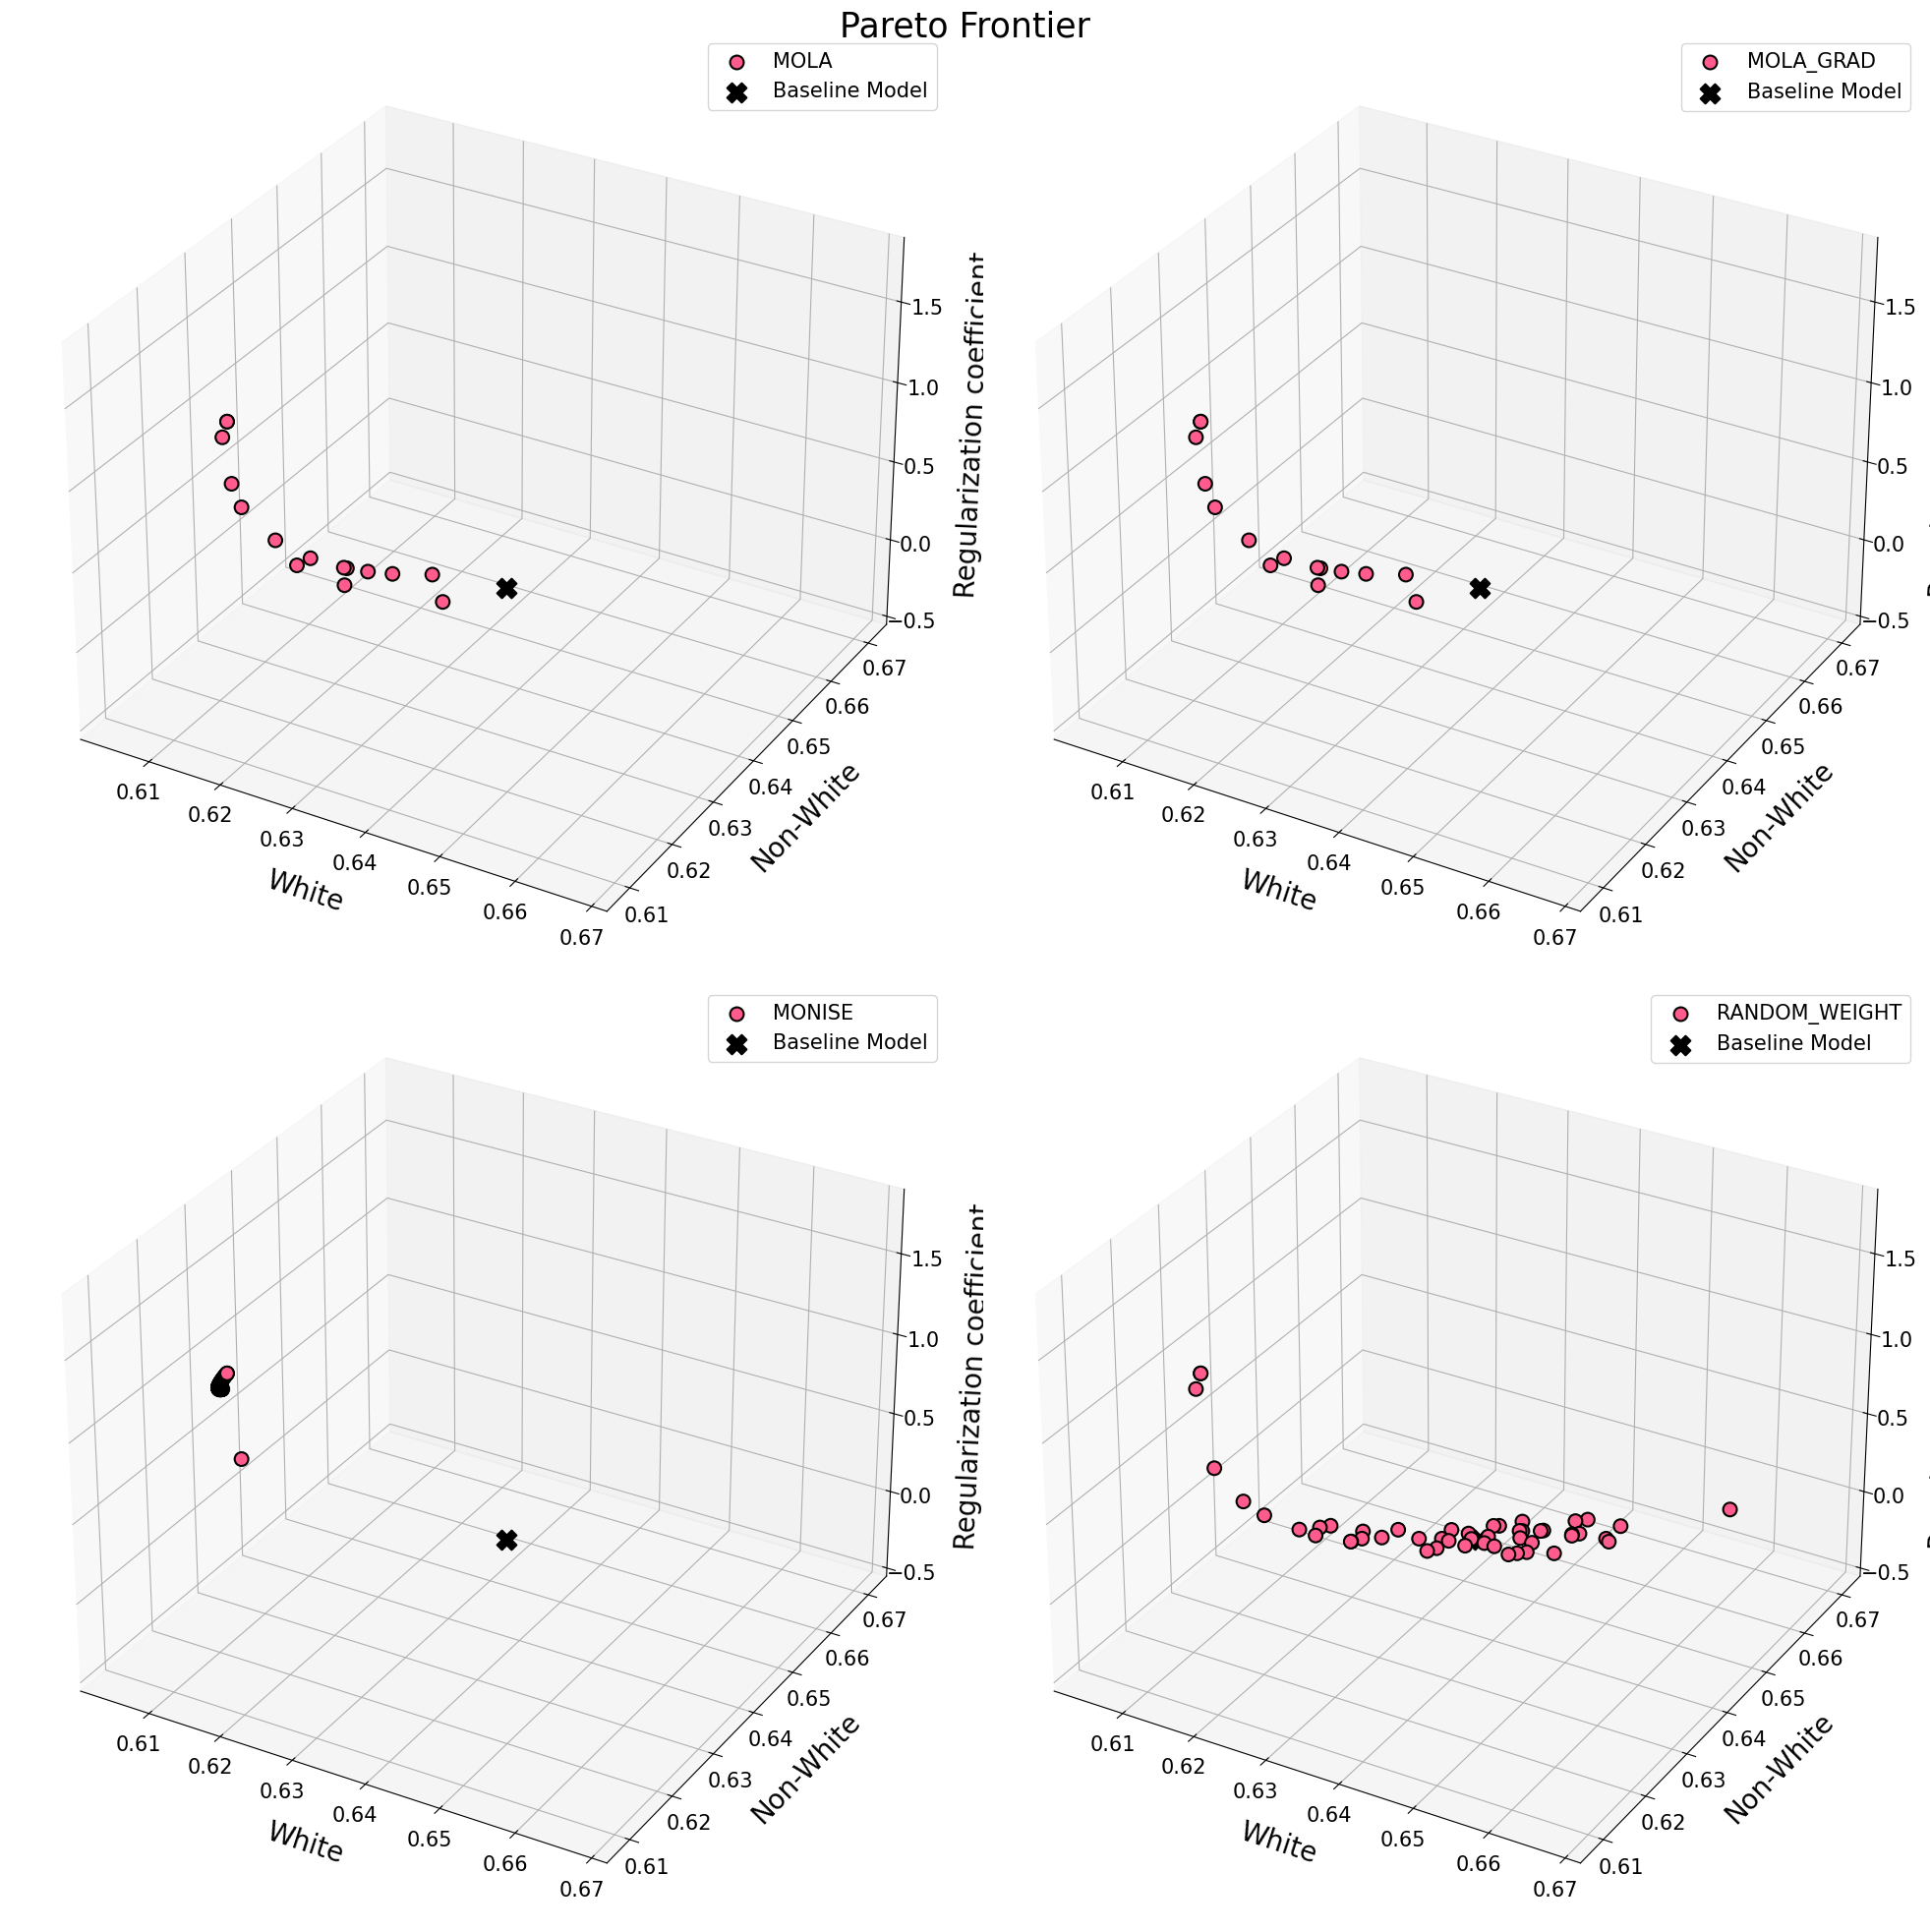

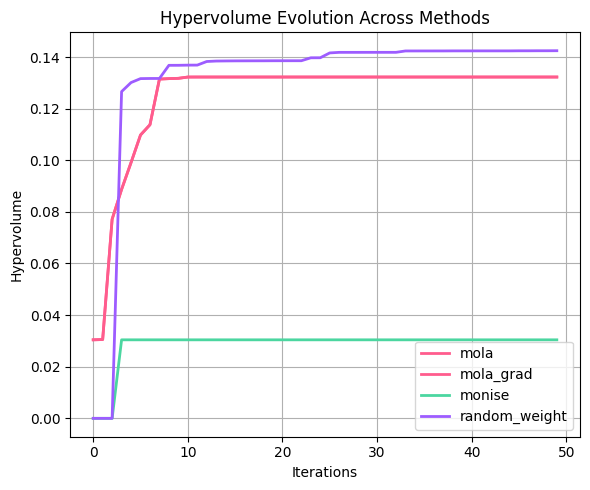

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
#colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
colors_hv = ['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6']
title = ""
axes_label = ["White", "Non-White", "Regularization coefficient"]

plot_pareto(methods=pareto_dict,
               labels=axes_label, 
               #title=title,
               point = equal.objs,
               color=colors_hv,
               save_path='images/3_objs_methods.png',
               figsize=(10,10),
               fontsize=20,
               s_factor=2
               )

plot_pareto_plotly(methods=pareto_dict,
            labels=axes_label, 
            # title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=15,
            figsize=(15,7),
            save_path='images/2_objs_methods_plotly.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)